In [1]:
import pandas as pd

In [2]:
from nsepy import get_history as gh
import datetime as dt

In [3]:
start = dt.datetime(2013,1,1)
end = dt.datetime(2021,12,28)
stk_data = gh(symbol='TATACOFFEE',start=start,end=end)


In [4]:
stk_data=stk_data[["Open","High","Low","Close"]]
stk_data.to_csv("Tatacoffee13_21.csv")

In [5]:
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()
data1= Ms.fit_transform(stk_data[["Open"]])
print("Len:",data1.shape)

Len: (2225, 1)


In [6]:
training_size = round(len(data1 ) * 0.80)
print(training_size)
X_train=data1[:training_size]
X_test=data1[training_size:]
print("X_train length:",X_train.shape)
print("X_test length:",X_test.shape)
y_train=data1[:training_size]
y_test=data1[training_size:]
print("y_train length:",y_train.shape)
print("y_test length:",y_test.shape)

1780
X_train length: (1780, 1)
X_test length: (445, 1)
y_train length: (1780, 1)
y_test length: (445, 1)


In [11]:
import warnings
warnings.filterwarnings("ignore")

In [19]:
from sklearn.metrics import mean_squared_error
trends=['n','t','c','ct']
orders=[(0,0,1),(0,0,2)]
from statsmodels.tsa.arima.model import ARIMA
for td in trends:
        
        #print(td)
        #trendslist.append(td)
    model = ARIMA(X_train, order=(0,0,3),trend=td,)
    model_fit = model.fit()
        # make prediction
    y_pred= model_fit.predict(len(X_train), len(data1)-1)
        #print(y_pred)
    from sklearn.metrics import r2_score
    mse=mean_squared_error(y_test,y_pred,squared=False)
    from stockFunctions import rmsemape
    print("Trend={}".format(td))
    rmsemape(y_test,y_pred)
    print("************")

Trend=n
RMSE-Testset: 0.06339535218779319
maPe-Testset: 0.9982585401564278
************
Trend=t
RMSE-Testset: 0.07863739994579641
maPe-Testset: 1167491688810.4502
************
Trend=c
RMSE-Testset: 0.16269608046553125
maPe-Testset: 2168467897532.722
************
Trend=ct
RMSE-Testset: 0.3547956710042607
maPe-Testset: 1950142007730.2842
************


In [23]:
len(y_pred)

445

In [23]:
i=1
td="n"
model = ARIMA(X_train, order=(0,0,1),trend=td)
model_fit = model.fit()
# make prediction
y_pred= model_fit.predict(len(X_train), len(data1)-1)
#print(y_pred)
from sklearn.metrics import r2_score
mse=mean_squared_error(y_test,y_pred,squared=False)
from stockFunctions import rmsemape
print("Trend={}".format(td))
rmsemape(y_test,y_pred)
print("************")

Trend=n
RMSE-Testset: 0.06339511863393993
maPe-Testset: 0.9980857829202923
************


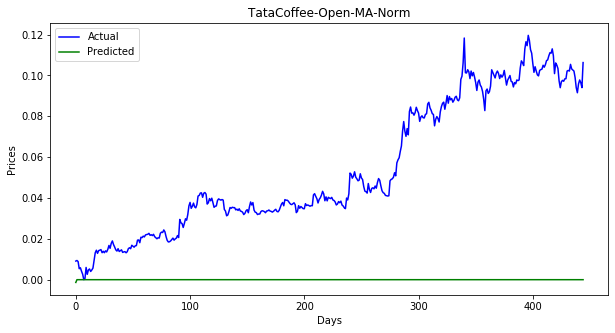

In [25]:
from stockFunctions import graph
graph(y_test,y_pred,"Actual","Predicted","TataCoffee-Open-MA-Norm","Days","Prices")

In [11]:
len(data1)

2225

In [26]:
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(y_test,["Open"])
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,["Open"])

In [27]:
from stockFunctions import conversionSingle
pTestNormTable=conversionSingle(y_pred,["Open"])
predicted_stock_price_test_ori=Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,["Open"])

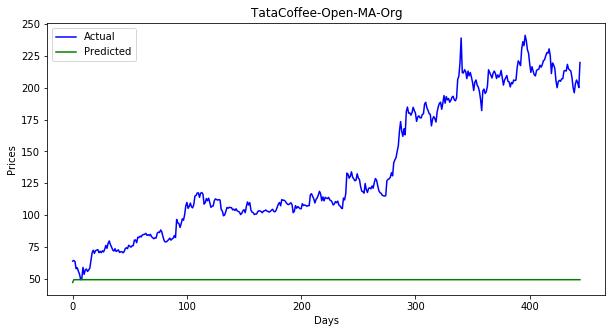

In [28]:
from stockFunctions import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","TataCoffee-Open-MA-Org","Days","Prices")

In [29]:
from stockFunctions import rmsemape
rmsemape(actual_stock_price_test_oriA,predicted_stock_price_test_oriP)

RMSE-Testset: 101.53362200411819
maPe-Testset: 0.5785632783152957


In [30]:
forecast=model_fit.predict(len(data1), len(data1)+30)

In [31]:
forecast

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [32]:
from stockFunctions import conversionSingle
fTestNormTable=conversionSingle(forecast,["Openfore"])
forecast_stock_price_test_ori=Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Openfore"])

In [33]:
forecast_stock_price_test_oriF

,Openfore
0,49.4
1,49.4
2,49.4
3,49.4
4,49.4
5,49.4
6,49.4
7,49.4
8,49.4
9,49.4


In [34]:
forecast_stock_price_test_oriF.to_csv("OpenMA.csv",index=False)